## EXPLORATORY DATA ANALYSIS OF IMAGES

#### 1- Importing the library

In [ ]:
import os
import sys, logging, pathlib
import matplotlib.pyplot as plt
import numpy as np


Note: you may need to restart the kernel to use updated packages.


In [2]:
%ls

01_data_ingestion.ipynb  02_data_eda.ipynb  FaceImages.zip  trials.ipynb


In [3]:
%pwd

'/home/donerick/FaceSystemRecognition-DeepFake-/research'

In [4]:
os.chdir("../")

In [5]:
%pwd

'/home/donerick/FaceSystemRecognition-DeepFake-'

#### Labelisation des images

In [6]:
from Face_Recognition_System import logger
import pandas as pd
data_path = pathlib.Path('artifacts/Human_Faces')
categories = {"Real_Images":0, "AI_Generated_Images":1}

def labelize_image(path_to_data: pathlib.Path):
    data = []
    for category, label in categories.items():
        folder_path = path_to_data / category
        
        # On liste tous les fichiers images
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
        for img_name in images:
            # On stocke le chemin relatif et le label
            data.append({
                'image_path': os.path.join(path_to_data, category, img_name),
                'label': label,
                'category': category
            })

    # 3. Création du DataFrame et sauvegarde en CSV
    df = pd.DataFrame(data)

    # Mélanger les données
    df = df.sample(frac=1).reset_index(drop=True) 

    # output csv file
    output_data_csv = 'artifacts/dataset_metadata.csv'
    df.to_csv(output_data_csv, index=False)
    logger.info(f"✅ Fichier CSV créé avec {len(df)} entrées in :{output_data_csv}")
    return df

if __name__=="__main__":
    df = labelize_image(data_path)
    df['category'].value_counts()

[2026-01-23 11:09:35,355: INFO: 2866685746: ✅ Fichier CSV créé avec 9630 entrées in :artifacts/dataset_metadata.csv]


### Display images

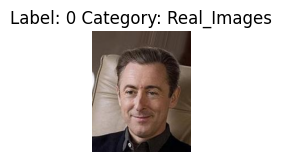

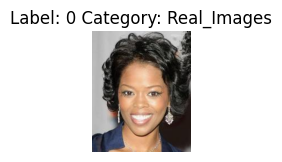

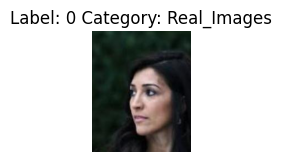

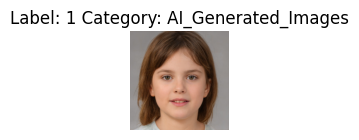

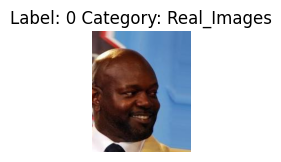

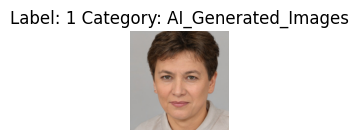

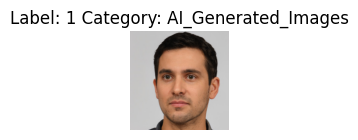

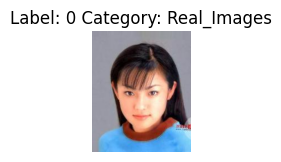

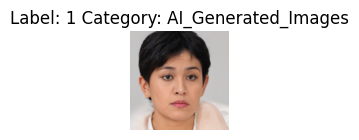

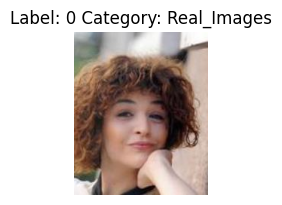

In [7]:
import matplotlib.pyplot as mpimg
from PIL import Image

def display_images(image_path: pathlib.Path,
                n_samples=10):
    samples = image_path.sample(n=n_samples).reset_index(drop=True)
    for i, (index, row) in enumerate(samples.iterrows()):
        plt.figure(figsize=(15, 6))
        plt.subplot(1, n_samples, i+1)
        img = mpimg.imread(row['image_path'])
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Label: {row['label']} Category: {row['category']}")

    plt.tight_layout()
    plt.show()


display_images(df, n_samples=10)
    

In [8]:
## taille et pixel des images
def image_size_distribution(image_paths: pd.DataFrame):
    sizes = []
    for index, row in image_paths.iterrows():
        img = Image.open(row['image_path'])
        sizes.append(img.size)  # (width, height)
    
    sizes_df = pd.DataFrame(sizes, columns=['width', 'height'])
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(sizes_df['width'], bins=30, color='blue', alpha=0.7)
    plt.title('Distribution of Image Widths')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Frequency')
    
    plt.subplot(1, 2, 2)
    plt.hist(sizes_df['height'], bins=30, color='green', alpha=0.7)
    plt.title('Distribution of Image Heights')
    plt.xlabel('Height (pixels)')
    plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

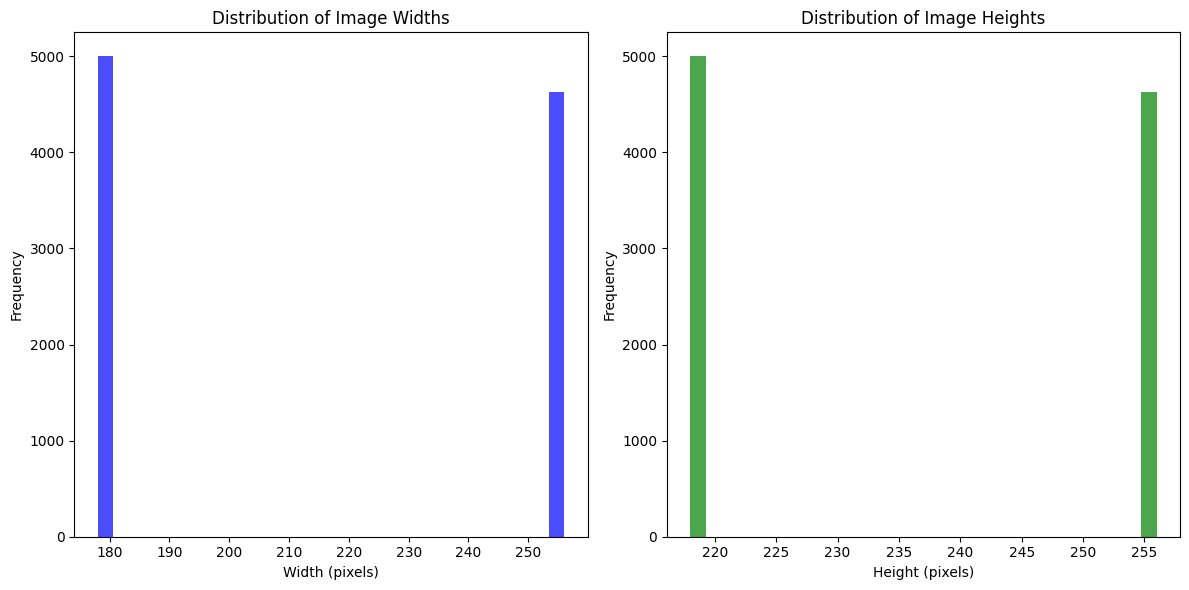

In [9]:
image_size_distribution(df)

### Projection des Images sur 3D

il s'agit de projeter les images sur 3D afin de voir si les donnÉes sont bien representÉes . 

##### 1- On utiliseras la technique de reduction de dimensionaité(UMAP, T-SNE, PCA)
##### 2- On utilise un modèle simple (MobileNet ou Resnet ) pour extraires les caratÉristiques(features) des images
##### 3- On compare les rÉsultats avec les 03 techniques


In [10]:
#%pip install umap-learn

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, MobileNetV2
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input as efficientnet_preprocess_input
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tensorflow.keras.preprocessing import image
import umap

2026-01-23 11:10:26.464863: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-23 11:10:27.337859: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-23 11:10:30.491553: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/donerick/FaceSystemRecognition-DeepFake-/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
from tqdm import tqdm

# 1. Chargement des données
df = pd.read_csv('artifacts/dataset_metadata.csv')
n_sample = 1000
df_sample = df.sample(n=n_sample, random_state=42).reset_index(drop=True)

# 2. Chargement du modèle UNE SEULE FOIS (en dehors de la boucle)
logger.info("Loading EfficientNetB0 model...")
base_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')

def get_single_feature(img_path):
    """Extrait les features pour une seule image."""
    try:
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = efficientnet_preprocess_input(x)
        feature = base_model.predict(x, verbose=0)
        return feature.flatten()
    except Exception as e:
        logger.error(f"Erreur sur l'image {img_path} : {e}")
        return None

# 3. Extraction avec barre de progression
logger.info(f"Extracting features for {n_sample} images...")
features_list = []
for path in tqdm(df_sample['image_path']):
    feat = get_single_feature(path)
    if feat is not None:
        features_list.append(feat)

features = np.array(features_list)
logger.info(f"Extracted features shape: {features.shape} ! Finished")

[2026-01-23 11:10:48,918: INFO: 1952145022: Loading EfficientNetB0 model...]


2026-01-23 11:10:48.932305: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[2026-01-23 11:10:51,698: INFO: 1952145022: Extracting features for 1000 images...]


100%|██████████| 1000/1000 [02:36<00:00,  6.40it/s]

[2026-01-23 11:13:27,849: INFO: 1952145022: Extracted features shape: (1000, 1280) ! Finished]


In [15]:
import plotly.express as px
logger.info("Réduction de dimensionnalité...")

# PCA 
features_array = np.array(features)
pca_3d = PCA(n_components=3).fit_transform(features_array)

# UMAP
reducer = umap.UMAP(n_components=3, random_state=42)
umap_3d = reducer.fit_transform(features_array)

# 4. Préparation de la visualisation Plotly
def plot_3d(projection, title):
    fig = px.scatter_3d(
        projection, x=0, y=1, z=2,
        color=df_sample['category'],
        title=title,
        labels={'0': 'PC1', '1': 'PC2', '2': 'PC3'},
        opacity=0.7
    )
    fig.show()

# Affichage des résultats
plot_3d(pca_3d, "Projection 3D via PCA")

[2026-01-23 11:49:06,003: INFO: 4282869976: Réduction de dimensionnalité...]


/home/donerick/FaceSystemRecognition-DeepFake-/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [13]:
plot_3d(umap_3d, "Projection 3D with UMAP")

***Constat et Conclusion***

D'après les résultats des réprésentations en 3D éffectués, on peut constater que :

*** 1- Avec PCA et UMAP, les images réelles réprésentés par des points bleu ont tendance à se regrouper dans une seule zone meme si quelques unes d'elles se mélangent avec les points oranges(Generated_Images_AI).***

*** 2- Les images générées par l'ia se dispersent dans toute la région de l'espace. Cela prouve que sans entrainement du modèle (Extracteur Efficientnet), la tache de deep learning semble très triviale.***

Conclusion : Les modèles pré-entrainés comme Efficientnet peuvent arriver à apprendre correctement avec quelques erreurs de près. Car En étant extracteur , il distingue les caractéristiques statistiques entre les images